# Customer Churn Prediction — Exploratory Data Analysis

## Objective

The objective of this analysis is to understand the characteristics of the customer dataset, evaluate data quality, and identify potential patterns associated with customer churn.

The insights obtained during the EDA will guide the preprocessing, feature engineering, and modeling stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv(
    "../data/raw/sales.csv"
)

## 1. Dataset Overview

The first step is to inspect the structure of the dataset, understand the available features, and identify potential data quality issues before performing any transformations.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### Initial observations

- The dataset contains 7,043 customer records and 21 features.
- Most variables are categorical.
- `tenure`, `MonthlyCharges`, and `TotalCharges` represent numerical customer information.
- `SeniorCitizen` is stored as an integer but represents a binary variable.
- `Churn` is the target variable.
- `TotalCharges` was initially detected as a string and requires further investigation.

## 2. Data Quality Assessment

Before performing the exploratory analysis, the dataset is checked for missing values, incorrect data types, duplicate records, inconsistent categories, and other potential data quality issues.

### 2.1 TotalCharges data type

`TotalCharges` was initially stored as a string despite representing a monetary value.

The column was inspected to identify values that could not be converted to a numeric format.

In [8]:
invalid_total_charges = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isna()

invalid_total_charges.sum()

np.int64(11)

In [9]:
df[invalid_total_charges]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


A total of 11 records contained empty `TotalCharges` values. All of these customers had `tenure = 0`, indicating that they were new customers with no accumulated charges yet.

Therefore, these values were interpreted as zero rather than being imputed using a statistical measure such as the mean or median.

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [13]:
df["TotalCharges"].dtype

dtype('float64')

### 2.2 Duplicate records and customer identifiers

The dataset is checked for duplicated records. Additionally, `customerID` is evaluated to verify that each row represents a unique customer.

In [14]:
df["customerID"].is_unique

True

In [15]:
df.duplicated().sum()

np.int64(0)

No duplicated records were found, and all 7,043 customers have a unique `customerID`.

The `customerID` variable will be retained for customer identification but excluded from the predictive features during modeling, since the identifier itself does not provide meaningful information for predicting churn.

### 2.3 Categorical variables

The categorical variables are inspected to identify inconsistent labels, unexpected categories, and understand the possible values of each feature.

In [16]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

In [17]:
categorical_columns = (
    df.select_dtypes(include=["object", "string"])
      .columns
      .drop("customerID")
)

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service   

The categorical variables appear to be consistently encoded, with no obvious spelling or formatting inconsistencies.

Some features contain categories such as `No internet service` and `No phone service`. These categories are kept separate from `No`, since they represent different customer situations rather than missing or equivalent values.

## 3. Target Variable Analysis

Before analyzing the relationship between customer characteristics and churn, the distribution of the target variable is examined to understand the degree of class imbalance.

In [18]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Approximately 73.5% of customers remained with the company, while 26.5% churned.

The target is therefore moderately imbalanced. This will be taken into account during model evaluation, as accuracy alone could provide a misleading assessment of model performance.

A naive classifier predicting `No Churn` for every customer would already achieve approximately 73.5% accuracy while identifying none of the customers who actually churn.

## 4. Numerical Feature Analysis

### 4.1 Customer Tenure

Customer tenure represents the number of months a customer has remained with the company.

The distribution of `tenure` is compared between customers who churned and those who remained to investigate whether customer longevity is associated with churn.

In [19]:
df["tenure"].groupby(df["Churn"]).describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


**Insight:** Customers who churned tend to have lower tenure than customers who remained. The median tenure for churned customers is 10 months, compared with 38 months for customers who did not churn.

**Business interpretation:** Churn appears to be particularly associated with customers in the earlier stages of their relationship with the company. This suggests that the company should investigate its early customer experience and consider retention initiatives targeted at newer customers, such as onboarding improvements, satisfaction surveys, or targeted retention offers.

#### Tenure distribution by churn status

A boxplot is used to compare the distribution of customer tenure between customers who churned and those who remained.

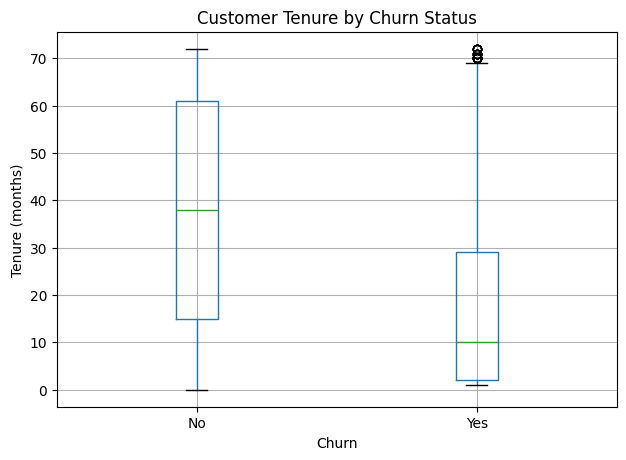

In [20]:
df.boxplot(
    column="tenure",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

The boxplot confirms the substantial difference in tenure between the two groups. Customers who churned generally have a lower tenure, with their distribution concentrated toward the earlier months of the customer relationship.

Several high-tenure observations appear as statistical outliers within the churn group. These records should not be considered errors, as they represent valid long-term customers who eventually left the company. This also indicates that churn is not exclusive to recently acquired customers.

#### Churn rate by tenure group

To better understand how churn varies throughout the customer lifecycle, customers are grouped into 12-month tenure intervals.

Since `ChurnBinary` is encoded as 1 for churn and 0 for non-churn, its mean within each tenure group represents the churn rate for that group.

In [21]:
df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [22]:
df[["Churn", "ChurnBinary"]].head()

,Churn,ChurnBinary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [23]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12",
        "13-24",
        "25-36",
        "37-48",
        "49-60",
        "61-72"
    ]
)

In [24]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12     2186
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64

In [25]:
tenure_analysis = (
    df.groupby("TenureGroup", observed=True)
      .agg(
          Customers=("customerID", "count"),
          ChurnRate=("ChurnBinary", "mean")
      )
)

tenure_analysis["ChurnRate"] *= 100

tenure_analysis

,Customers,ChurnRate
TenureGroup,,
0-12,2186,47.438243
13-24,1024,28.710938
25-36,832,21.634615
37-48,762,19.028871
49-60,832,14.423077
61-72,1407,6.609808


**Insight:** Churn rate decreases substantially as customer tenure increases. Customers within their first 12 months have the highest observed churn rate (47.4%), while customers with 61–72 months of tenure show a churn rate of only 6.6%.

The decline is consistent across the tenure groups, suggesting a strong association between customer longevity and retention.

**Business interpretation:** The first year of the customer relationship appears to be a particularly important period for retention. The company could prioritize further investigation of the early customer experience and evaluate targeted retention strategies for recently acquired customers.

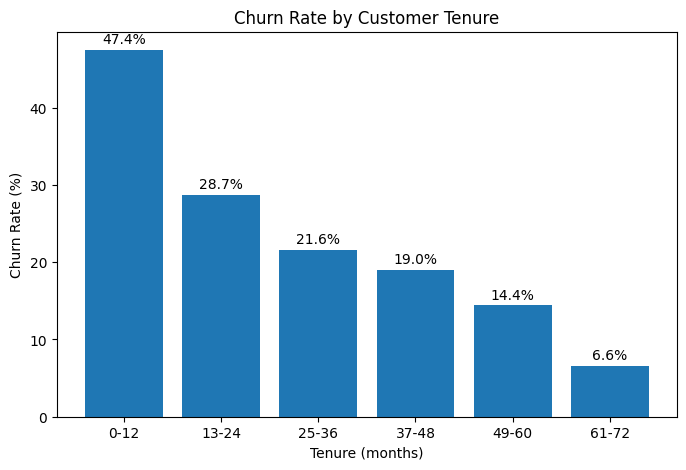

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    tenure_analysis.index,
    tenure_analysis["ChurnRate"]
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

### 4.2 Monthly Charges


In [27]:
df["MonthlyCharges"].groupby(df["Churn"]).describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


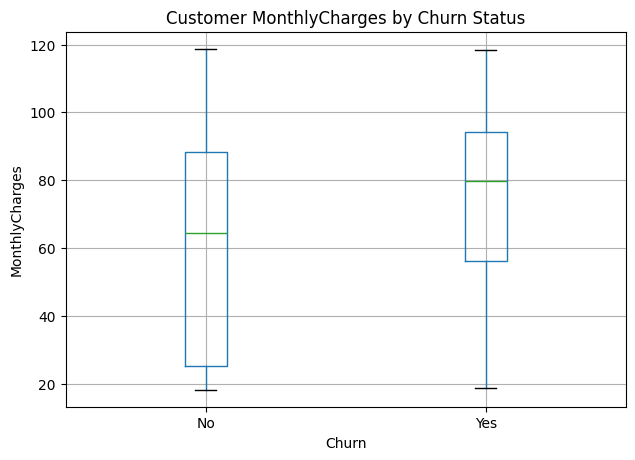

In [28]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Customer MonthlyCharges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

The distribution of monthly charges is compared between customers who churned and those who remained.

Customers who churned tend to have higher monthly charges. The median monthly charge is approximately $79.65 for churned customers, compared with $64.43 for non-churned customers.

The boxplot confirms this difference, showing that the distribution of monthly charges for churned customers is generally shifted toward higher values.

This suggests an association between higher monthly charges and churn, although this relationship should be interpreted together with other customer characteristics.

### 4.3 Total Charges



In [29]:
df["TotalCharges"].groupby(df["Churn"]).describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


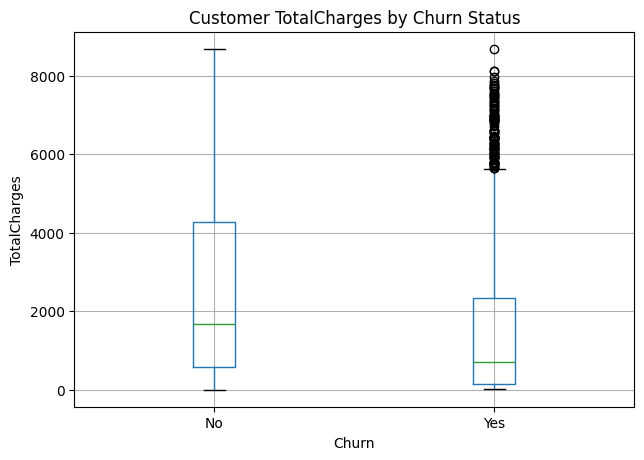

In [30]:
df.boxplot(
    column="TotalCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Customer TotalCharges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("TotalCharges")
plt.show()

Customers who churned have substantially lower accumulated total charges than customers who remained. The median `TotalCharges` is approximately $703.55 for churned customers, compared with $1,679.53 for non-churned customers.

Although churned customers tend to have higher monthly charges, they also tend to have much shorter tenure. This shorter customer relationship likely contributes to the lower accumulated charges observed among churned customers.

This highlights the importance of analyzing `TotalCharges` together with `tenure` and `MonthlyCharges`, rather than interpreting these variables independently.

## 5. Categorical Feature Analysis

Categorical customer characteristics are analyzed to identify whether churn rates differ across customer groups.

### 5.1 Contract Type

The churn rate is compared across contract types to investigate whether customer commitment is associated with customer retention.

In [31]:
contract_analysis = df.groupby("Contract", observed=True).agg(
    Customers=("customerID", "count"),
    ChurnRate=("ChurnBinary", "mean")
)
contract_analysis["ChurnRate"] *= 100
contract_analysis

,Customers,ChurnRate
Contract,,
Month-to-month,3875,42.709677
One year,1473,11.269518
Two year,1695,2.831858


**Insight:** Churn rate varies substantially across contract types. Month-to-month customers have the highest observed churn rate (42.7%), compared with 11.3% for one-year contracts and only 2.8% for two-year contracts.

This indicates a strong association between contract type and customer churn. However, this relationship should not be interpreted as causal, since contract type may also be related to other customer characteristics such as tenure.

**Business interpretation:** Month-to-month customers represent a particularly relevant segment for further retention analysis. The company could investigate the reasons behind their higher churn rate and evaluate whether incentives for longer-term contracts could improve retention.

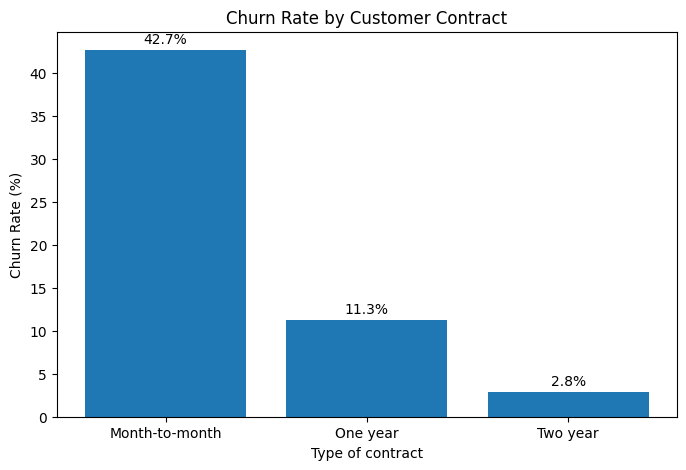

In [32]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_analysis.index,
    contract_analysis["ChurnRate"]
)

plt.title("Churn Rate by Customer Contract")
plt.xlabel("Type of contract")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

### 5.2 Internet Service

Churn rates are compared across the different types of internet service.

In [33]:
internet_analysis = df.groupby("InternetService", observed=True).agg(
    Customers=("customerID", "count"),
    ChurnRate=("ChurnBinary", "mean")
)
internet_analysis["ChurnRate"] *= 100
internet_analysis

,Customers,ChurnRate
InternetService,,
DSL,2421,18.959108
Fiber optic,3096,41.892765
No,1526,7.404980


**Insight:** Customers with fiber optic service show the highest observed churn rate (41.9%), compared with 19.0% for DSL customers and 7.4% for customers without internet service.

This indicates an association between internet service type and churn. However, the difference should not be interpreted as causal, since other customer characteristics such as monthly charges, contract type, or tenure may also differ across these groups.

**Business interpretation:** Fiber optic customers represent a relevant segment for further investigation. Understanding whether their higher churn rate is associated with pricing, contract characteristics, service experience, or other factors could help identify potential retention opportunities.

#### Internet Service and Monthly Charges

Fiber optic customers have substantially higher monthly charges than customers using DSL or customers without internet service.

The median monthly charge is approximately $91.68 for fiber optic customers, compared with $56.15 for DSL customers and $20.15 for customers without internet service.

This is particularly relevant because fiber optic customers also showed the highest churn rate in the previous analysis. Therefore, the higher churn observed among fiber optic customers may be related to multiple characteristics, including their higher monthly charges.

Further analysis and predictive modeling will help determine how these variables contribute to churn when considered together.

In [34]:
df["MonthlyCharges"].groupby(df["InternetService"]).describe()

,count,mean,std,min,25%,50%,75%,max
InternetService,,,,,,,,
DSL,2421.0,58.102169,16.259522,23.45,46.20,56.150,69.90,94.80
Fiber optic,3096.0,91.500129,12.663039,67.75,80.55,91.675,101.15,118.75
No,1526.0,21.079194,2.164221,18.25,19.70,20.150,20.90,26.90


<Axes: title={'center': 'MonthlyCharges'}, xlabel='InternetService'>

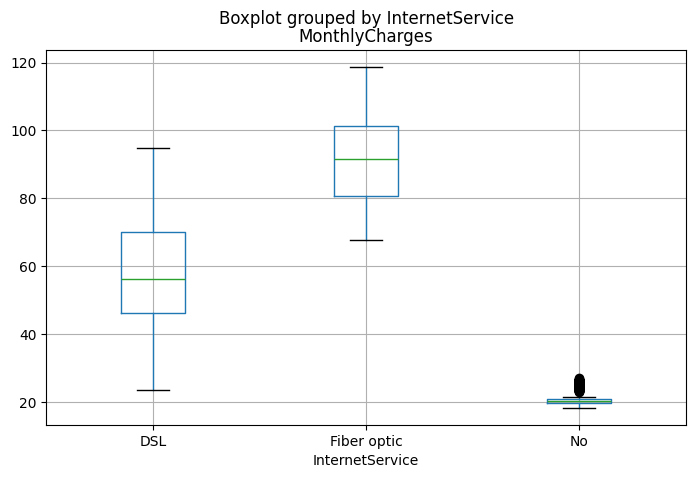

In [35]:
df.boxplot(
    column="MonthlyCharges",
    by="InternetService",
    figsize=(8, 5)
)

In [36]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod"
]

In [37]:
for feature in categorical_features:
    analysis = df.groupby(feature)["ChurnBinary"].mean() * 100
    print(f"\n--- {feature} ---")
    print(analysis)



--- gender ---
gender
Female    26.920872
Male      26.160338
Name: ChurnBinary, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
0    23.606168
1    41.681261
Name: ChurnBinary, dtype: float64

--- Partner ---
Partner
No     32.957979
Yes    19.664903
Name: ChurnBinary, dtype: float64

--- Dependents ---
Dependents
No     31.279140
Yes    15.450237
Name: ChurnBinary, dtype: float64

--- PhoneService ---
PhoneService
No     24.926686
Yes    26.709637
Name: ChurnBinary, dtype: float64

--- MultipleLines ---
MultipleLines
No                  25.044248
No phone service    24.926686
Yes                 28.609896
Name: ChurnBinary, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: ChurnBinary, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: ChurnBinary, dtype: float64

--- D

### 5.3 Payment Method

Churn rates vary substantially across payment methods.

Customers using electronic check show the highest observed churn rate (45.3%), compared with approximately 15–19% among customers using the other payment methods.

This indicates a strong association between electronic check payments and customer churn. However, this exploratory analysis does not establish a causal relationship. Other customer characteristics may differ across payment method groups and contribute to the observed pattern.

**Business interpretation:** Customers using electronic check represent a relevant segment for further investigation. Understanding the characteristics of these customers and the reasons behind their higher churn rate could help identify potential retention opportunities.

In [38]:
payment_analysis = df.groupby("PaymentMethod", observed=True).agg(
    Customers=("customerID", "count"),
    ChurnRate=("ChurnBinary", "mean")
)
payment_analysis["ChurnRate"] *= 100
payment_analysis

,Customers,ChurnRate
PaymentMethod,,
Bank transfer (automatic),1544,16.709845
Credit card (automatic),1522,15.243101
Electronic check,2365,45.285412
Mailed check,1612,19.106700


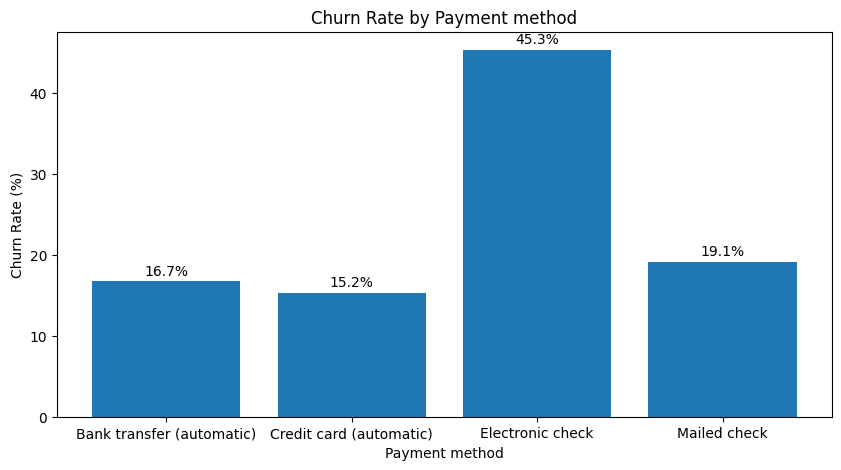

In [39]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    payment_analysis.index,
    payment_analysis["ChurnRate"]
)

plt.title("Churn Rate by Payment method")
plt.xlabel("Payment method")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

### 5.4 Technical Support and Internet Service

To investigate whether the association between technical support and churn could be explained by internet service type, churn rates were calculated separately for DSL and fiber optic customers.

Among DSL customers, the observed churn rate decreases from 27.8% without technical support to 9.7% with technical support. A similar pattern appears among fiber optic customers, where churn decreases from 49.4% to 22.6%.

Therefore, the association between technical support and lower churn persists within both internet service groups. However, this remains an observational relationship and should not be interpreted as evidence that technical support directly causes lower churn.

In [40]:
df.groupby(["InternetService", "TechSupport"]).agg(
    ChurnRate=("ChurnBinary", "mean")
)

ChurnRate
InternetService TechSupport                   
DSL             No                    0.277554
                Yes                   0.096774
Fiber optic     No                    0.493722
                Yes                   0.226328
No              No internet service   0.074050

### 5.5 Paperless Billing

Customers using paperless billing show a substantially higher observed churn rate (33.6%) than customers not using paperless billing (16.3%).

Further analysis showed that payment method is associated with paperless billing. Electronic check is used by 41.8% of customers with paperless billing, compared with 21.7% of customers without paperless billing. This is relevant because electronic check customers also showed a particularly high churn rate.

However, differences in payment method do not fully explain the observed association. Within every payment method, customers using paperless billing still show higher churn rates than customers not using paperless billing.

This suggests that `PaperlessBilling` may provide additional predictive information about churn, although these observational results should not be interpreted as evidence of a causal relationship.

In [41]:
payment_distribution = pd.crosstab(
    df["PaperlessBilling"],
    df["PaymentMethod"],
    normalize="index"
) * 100

payment_distribution

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
PaperlessBilling,,,,
No,22.736769,22.284123,21.692201,33.286908
Yes,21.361784,21.146008,41.764565,15.727643


In [42]:
df.groupby(
    ["PaperlessBilling", "PaymentMethod"]
)["ChurnBinary"].mean() * 100

PaperlessBilling  PaymentMethod            
No                Bank transfer (automatic)    11.026034
                  Credit card (automatic)      10.000000
                  Electronic check             32.744783
                  Mailed check                 13.493724
Yes               Bank transfer (automatic)    20.875421
                  Credit card (automatic)      19.047619
                  Electronic check             49.770379
                  Mailed check                 27.286585
Name: ChurnBinary, dtype: float64

## 6. Key EDA Insights

The exploratory data analysis revealed several customer characteristics that show clear associations with churn.

### Customer Tenure

Customer tenure shows a strong relationship with churn. Customers within their first 12 months have the highest observed churn rate (47.4%), while customers with 61–72 months of tenure show a churn rate of only 6.6%.

This suggests that the early stages of the customer relationship represent a particularly important period for customer retention.

### Monthly Charges

Customers who churned tend to have higher monthly charges. The median monthly charge among churned customers is approximately $79.65, compared with $64.43 among customers who remained.

This suggests an association between higher monthly charges and customer churn, although other customer characteristics may also contribute to this relationship.

### Contract Type

Contract type shows substantial differences in churn rates. Month-to-month customers have an observed churn rate of 42.7%, compared with 11.3% for one-year contracts and only 2.8% for two-year contracts.

Month-to-month customers therefore represent a particularly relevant segment for further retention analysis.

### Payment Method

Customers using electronic check show a substantially higher observed churn rate (45.3%) than customers using other payment methods, whose churn rates range approximately between 15% and 19%.

This suggests a strong association between electronic check payments and customer churn.

### Technical Support

Technical support is also associated with substantial differences in churn. Among DSL customers, churn decreases from 27.8% for customers without technical support to 9.7% for customers with technical support.

A similar pattern is observed among fiber optic customers, where churn decreases from 49.4% without technical support to 22.6% with technical support.

The association between technical support and lower churn therefore persists within both internet service groups.

### Overall Findings

The EDA suggests that churn is not associated with a single customer characteristic. Instead, several aspects of the customer relationship appear to be relevant, particularly customer tenure, monthly charges, contract type, payment method, and technical support.

These findings will guide the preprocessing and modeling stages, where the variables will be evaluated jointly to determine their predictive value.

The relationships identified during this analysis are observational and should not be interpreted as causal effects.